In [18]:
# auto reload modules
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import wilcoxon, shapiro, friedmanchisquare, f_oneway, ttest_rel
from matplotlib.colors import to_rgba
import statsmodels.stats.multitest as smm
from globalVars import *
from load_data_pickles import *
from plotting_variables import TINY_SIZE

# pilot subject data with passthrough interface

In [4]:
# pilot subject data (N = 6) with pass-through interface (I = 1), with non-min-phase second order machine
with open(data_path+'pilot_subjects_passthrough.pkl', 'rb') as file:
    Gs_base, Hs_base, Ds_base, UHs_base, UGs_base, Ys_base, ds_base, uhs_base, ugs_base, ys_base, errors_base = pickle.load(file)

#average over all trials and subjects
H_pilot = np.mean(Hs_base, axis = (0,1))

In [5]:
H_pilot[IX]

array([0.39291462-0.37899065j, 0.38733117-0.31311169j,
       0.33776018-0.25368955j, 0.34470355-0.25093759j,
       0.36380918-0.26979612j, 0.41433603-0.27311936j,
       0.50511606-0.42402896j, 0.50547373-0.53465292j])

# Baseline interfaces

In [6]:
def loss(H, G, order,lamH = 1.5,lamG = 0.5): #D = disturbance (freq); d = disturbance (time domain) shape = (2400,)
    if order=='second':
        G_ = second(G)
    elif order=='first':
        G_ = first(G)
    elif order=='zero':
        G_ = zero(G)
    else:
        print('something is wrong')
    print(G_.shape)
    D = polar2rec(amps) # D = disturbance (freq) at stim freqs        
    Y = [D[f]/(1+soM[f]*G_[f]*H[f]) for f in range(len(soM))] # when d is output disturbnace, Y = D/(1+MIH)
    Y = np.asarray(Y) #a function of G, shape = (8,100)

    # interface input and human input
    UH = [-Y[f]*H[f] for f in range(len(soM))] #U_H = -Y*H, (freq domain)
    UG = [-Y[f]*H[f]*G_[f] for f in range(len(soM))] #U_I = -Y*H*I, (freq domain)
    UH = np.asarray(UH) #a function of G, shape = (8,100)
    UG = np.asarray(UG)  #a function of G, shape = (8,100)

    # 2 norm
    losses = (np.sum(abs(Y)**2,axis=0) + lamH*np.sum(abs(UH)**2,axis=0) + lamG*np.sum(abs(UG)**2,axis=0))/np.sum(abs(D)**2,axis=0)

    return losses, Y, UH, UG

In [11]:
# find the interface with the smallest loss

# 0th-order 
lamH = 1.5
lamG = 0.5
losses_0th, Y_0th, UH_0th, UG_0th = loss(H_pilot[IX], zero_order_Gs, order = 'zero',lamH = lamH,lamG = lamG)
print(losses_0th.shape)
idx_min0 = np.argmin(losses_0th)
print('idx_min = ',idx_min0)
G_star0 = zero_order_Gs[idx_min0]
print('I* 0th order = ',G_star0)
print('losses_0th = ',losses_0th[idx_min0])
G_star_freq0 = zero(G_star0)

print('\n')

# 1st-order
losses_1st, Y_1st, UH_1st, UG_1st = loss(H_pilot[IX], first_order_Gs, order = 'first',lamH = lamH,lamG = lamG)
print(losses_1st.shape)
idx_min1 = np.argmin(losses_1st)
print('idx_min = ',idx_min1)
G_star1 = first_order_Gs[:,idx_min1]
print('losses_1st = ',losses_1st[idx_min1])
print('I* 1st order = ',G_star1)
G_star_freq1 = first(G_star1)

print('\n')

# 2nd-order
losses_2nd, Y_2nd, UH_2nd, UG_2nd = loss(H_pilot[IX], second_order_Gs, order = 'second',lamH = lamH,lamG = lamG)
print(losses_2nd.shape)
idx_min2 = np.argmin(losses_2nd)
print('idx_min = ',idx_min2)
G_star2 = second_order_Gs[:,idx_min2]
print('losses_2nd = ',losses_2nd[idx_min2])
print('I* 2nd order = ',G_star2)
G_star_freq2 = second(G_star2)


(8, 100)
(100,)
idx_min =  99
I* 0th order =  5.0
losses_0th =  1.3297506806646429


(8, 8546)
(8546,)
idx_min =  1536
losses_1st =  1.1047596324517108
I* 1st order =  [-0.97694596  1.55       -1.55      ]


(8, 87038)
(87038,)
idx_min =  5277
losses_2nd =  0.9661582379975997
I* 2nd order =  [-1.9886095   0.98873708  1.06020408 -2.12034041  1.06013633]


loss for 0th =  1.3297506806646429
loss for 1st =  1.1047596324517108
loss for 2nd =  0.9661582379975997




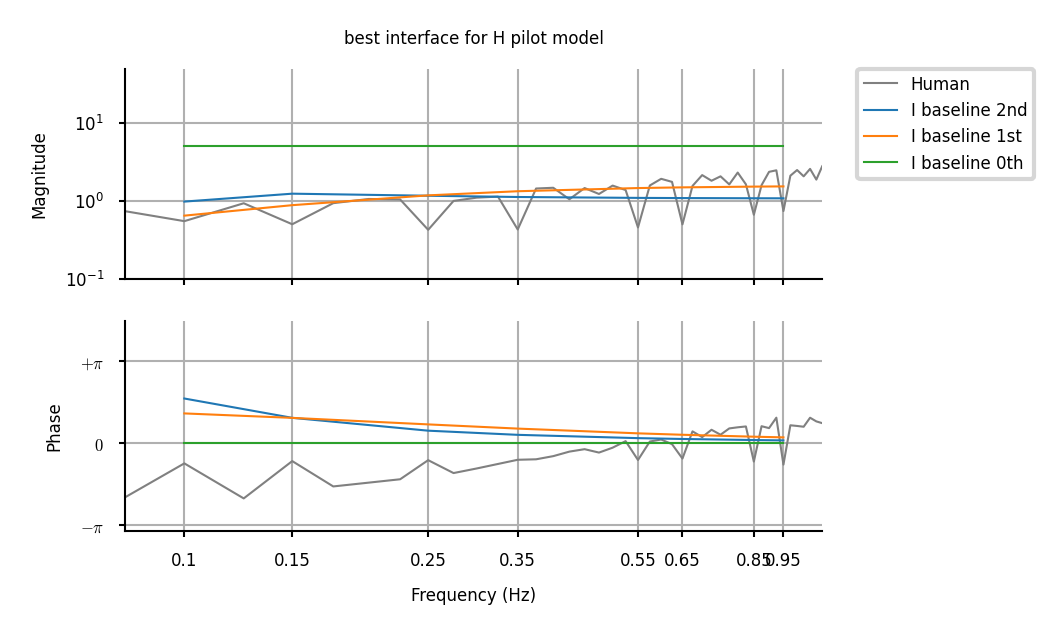

In [ ]:
print('loss for 0th = ', losses_0th[idx_min0])
print('loss for 1st = ', losses_1st[idx_min1])
print('loss for 2nd = ', losses_2nd[idx_min2])
print('\n')
fig, axs = plt.subplots(2,1, figsize = (3,2),sharex = 'col', sharey = 'row',dpi = 300)
ylimphase = (-np.pi-0.2,1.5*np.pi)
yticksphase = [-np.pi,0.,np.pi]
yticklabelsphase = [r'$-\pi$',r'$0$',r'$+\pi$']
xlim = (0,21*base_freq)
xticks = primes*0.05
xticklabels =np.round(primes*0.05,2)

ax = axs[0]
ax.plot(xf, np.abs(H_pilot[:N//2]), color = 'grey',label = 'Human') # H when interface is 1 (passthough)
ax.plot(freqs, np.abs(G_star_freq2), color = python_colors[0], label = 'I baseline 2nd')
ax.plot(freqs, np.abs(G_star_freq1), color = python_colors[1], label = 'I baseline 1st')
ax.plot(freqs, np.abs(G_star_freq0), color = python_colors[2], label = 'I baseline 0th')
ax.set_ylabel('Magnitude')
ax.set_xlim(0.08,1.1)
ax.set_ylim(0.1,50)
ax.set_xscale("log")
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels,rotation=45)
ax.grid('on',zorder=-1)
ax.set_yscale("log")


ax = axs[1]
ax.plot(xf, np.angle(H_pilot[:N//2]), color = 'grey', label = 'Human')
ax.plot(freqs, np.angle(G_star_freq2), color = python_colors[0], label = 'I baseline 2nd')
ax.plot(freqs, np.angle(G_star_freq1), color = python_colors[1], label = 'I baseline 1st')
ax.plot(freqs, np.angle(G_star_freq0), color = python_colors[2], label = 'I baseline 0th')
ax.set_ylabel('Phase') 
ax.set_xlabel('Frequency (Hz)')
ax.grid('on',zorder=-1)
ax.set_ylim(ylimphase)
ax.set_yticks(yticksphase)
ax.set_yticklabels(yticklabelsphase)
axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
axs[0].set_title('best interface for H pilot model')
plt.show()